# EFM Generation: Colored MNIST 32x32

In [1]:
import torch
import torchvision

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#import wandb
#import sys
#sys.path.append("/trinity/home/a.kolesov/EFM/")

import sys
from pathlib import Path

# Get the directory where the current notebook is located
notebook_dir = Path().resolve()

# Go one level up to the project root (assuming 'src' is there)
project_root = notebook_dir.parent

# Add the project root to Python's path
sys.path.append(str(project_root))

In [2]:
import sys
import collections
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

class NotebookLogger:
    def __init__(self, scalar_plot_every=200):
        self.scalar_plot_every = scalar_plot_every
        self._scalars = collections.defaultdict(list)
        self._last_plot_step = -1
        self._initialized = True

    def init(self, **kwargs):
        print(f"[Logger] experiment: {kwargs.get('name', 'unnamed')}")
        return self

    def log(self, metrics: dict, step: int = 0):
        for key, value in metrics.items():
            if isinstance(value, plt.Figure):
                print(f"[step {step}] {key}")
                display(value)
                plt.close(value)
            else:
                self._scalars[key].append((step, float(value)))

        if step - self._last_plot_step >= self.scalar_plot_every:
            self._plot_scalars(step)
            self._last_plot_step = step

    def _plot_scalars(self, current_step):
        if not self._scalars:
            return
        keys = list(self._scalars.keys())
        n = len(keys)
        fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
        if n == 1:
            axes = [axes]
        for ax, key in zip(axes, keys):
            data = self._scalars[key]
            steps = [d[0] for d in data]
            vals  = [d[1] for d in data]
            ax.plot(steps, vals)
            ax.set_title(key)
            ax.set_xlabel("step")
            ax.grid(True)
        fig.tight_layout()
        clear_output(wait=True)
        display(fig)
        plt.close(fig)

# Глобальная подмена wandb
sys.modules['wandb'] = NotebookLogger()

In [3]:
from src_new.models import DDPM, ExponentialMovingAverage
from src_new.efm_field import EFM
from src_new.utils import Config, optimization_manager, random_color

## 1. Base Config

In [4]:
config = Config()

config.data = Config()
config.data.name = 'MNIST'
config.data.num_channels = 1
config.data.img_resize = 16 #was 32
config.data.image_size= 16 #was 32
config.data.centered = True

config.device = 'cuda'
config.L = 30 #was 500 # important parameter
config.DIM = config.data.num_channels*config.data.image_size*config.data.image_size + 1

config.p = Config()
config.p.x_loc = 0.

config.q = Config()
config.q.x_loc = config.L


config.training = Config()
config.training.small_batch_size =64 # important parameter
config.training.batch_size =64      # important parameter
config.training.n_iters = 1_000_000
config.training.sde = 'poisson'
config.training.eval_freq = 1_000
config.training.snapshot_freq = 1_000
config.training.sigma_end = 0.1
config.training.M = 291 # important parameter
config.training.tau = 0.03  
config.training.epsilon = 1e-3 # important parameter
config.training.interpolation = 'Uniform_mixing'
config.training.restrict_M = False
config.training.stability = True
config.training.gamma = 5. # important parameter


config.model  = Config()

config.model = config.model
config.model.name = 'ncsnpp'
config.model.scale_by_sigma = False
config.model.ema_rate = 0.9999
config.model.normalization = 'GroupNorm'
config.model.nonlinearity = 'swish'
config.model.nf = 128
config.model.ch_mult = (1, 2, 2, 2)
config.model.num_res_blocks = 4
config.model.attn_resolutions = (16,)
config.model.resamp_with_conv = True
config.model.conditional = True
config.model.fir = False
config.model.fir_kernel = [1, 3, 3, 1]
config.model.skip_rescale = True
config.model.resblock_type = 'biggan'
config.model.progressive = 'none'
config.model.progressive_input = 'none'
config.model.progressive_combine = 'sum'
config.model.attention_type = 'ddpm'
config.model.init_scale = 0.
config.model.fourier_scale = 16
config.model.embedding_type = 'positional'
config.model.conv_size = 3
config.model.sigma_end = 0.1
config.model.dropout = 0.1

config.optim  = Config()
config.optim.weight_decay = 0
config.optim.optimizer = 'Adam'
config.optim.lr = 2e-4
config.optim.beta1 = 0.9
config.optim.eps = 1e-8 
config.optim.warmup = 5000  
config.optim.grad_clip = 1.


config.ode = Config()
config.ode.gamma = 1e-7
config.ode.step = 0.25

config.sampling = Config()
config.sampling.method = 'ode'
config.sampling.ode_solver = 'rk45'
config.sampling.N = 100
config.sampling.z_max = config.L# - config.training.epsilon
config.sampling.z_min = config.training.epsilon
config.sampling.upper_norm = 3000
config.sampling.z_exp=1
config.sampling.vs = False
config.sampling.visual_iterations=10

In [5]:
##### running configuration #####
config.L = 30 #was 500
config.q.x_loc = config.L
config.training.small_batch_size = 64 #previous training was 32
config.training.batch_size = 64 #previous training was 32


config.training.interpolation = 'Uniform_mixing'
config.training.sigma_end = 0.1
config.training.M = 291 
config.training.tau = 0.03  
config.training.epsilon = 1e-3 
config.training.gamma = 5.

config.sampling.z_min = config.training.epsilon
config.sampling.z_max = config.L# - config.training.epsilon
##### running configuration #####

In [6]:
'''
# Ускоренное обучение для 16x16 ColoredMNIST
config.training.n_iters = 250_000           # было 1_000_000
config.training.batch_size = 128            # было 32 (если влезает в GPU)
config.training.small_batch_size = 128      # синхронизировать

# Упрощаем EFM параметры
config.L = 256                              # было 500
config.training.M = 120                     # было 291
config.training.gamma = 2.0                 # было 5.0
config.training.tau = 0.05                  # слегка увеличим (0.03 → 0.05)

# Упрощаем модель
config.model.nf = 64                        # было 128
config.model.ch_mult = (1, 2, 2)            # было (1,2,2,2)
config.model.num_res_blocks = 2             # было 4
# Для 16x16 внимания на разрешении 16 не нужно – убираем
config.model.attn_resolutions = ()          # было (16,)
'''

'\n# Ускоренное обучение для 16x16 ColoredMNIST\nconfig.training.n_iters = 250_000           # было 1_000_000\nconfig.training.batch_size = 128            # было 32 (если влезает в GPU)\nconfig.training.small_batch_size = 128      # синхронизировать\n\n# Упрощаем EFM параметры\nconfig.L = 256                              # было 500\nconfig.training.M = 120                     # было 291\nconfig.training.gamma = 2.0                 # было 5.0\nconfig.training.tau = 0.05                  # слегка увеличим (0.03 → 0.05)\n\n# Упрощаем модель\nconfig.model.nf = 64                        # было 128\nconfig.model.ch_mult = (1, 2, 2)            # было (1,2,2,2)\nconfig.model.num_res_blocks = 2             # было 4\n# Для 16x16 внимания на разрешении 16 не нужно – убираем\nconfig.model.attn_resolutions = ()          # было (16,)\n'

## 2. Data

In [7]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [8]:
TRANSFORM = torchvision.transforms.Compose([
    torchvision.transforms.Resize(config.data.img_resize),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.5],[0.5])
])

train_data = torchvision.datasets.MNIST(root='./data/',
                                        train=True, download=True, transform=TRANSFORM)
eval_data = torchvision.datasets.MNIST(root='./data/',
                                       train=False, download=True, transform=TRANSFORM)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=config.training.batch_size,
                                           shuffle=True)
eval_loader = torch.utils.data.DataLoader(eval_data, batch_size=config.training.batch_size,
                                          shuffle=True)

train_iter = iter(train_loader)
eval_iter = iter(eval_loader)

## 3. Models

In [9]:
net = DDPM(config).to(config.device)
params = net.parameters()
optimizer = torch.optim.Adam(params,
                       lr=config.optim.lr, betas=(config.optim.beta1, 0.999), eps=config.optim.eps,
                       weight_decay=config.optim.weight_decay)

ema = ExponentialMovingAverage(net.parameters(), decay=config.model.ema_rate)
state = dict(optimizer=optimizer, model=net, ema=ema, step=0)
optimize_fn = optimization_manager(config)

## 4. Training

In [10]:
config.name_exp = f"Int={config.training.interpolation}_\
            eps={config.training.epsilon}_\
            BS_{config.training.batch_size}_SBS={config.training.small_batch_size}\
            _L_{config.L}_sigma={config.training.sigma_end}"
#wandb.init(project="EFMGenerationCMNIST", name=config.name_exp)


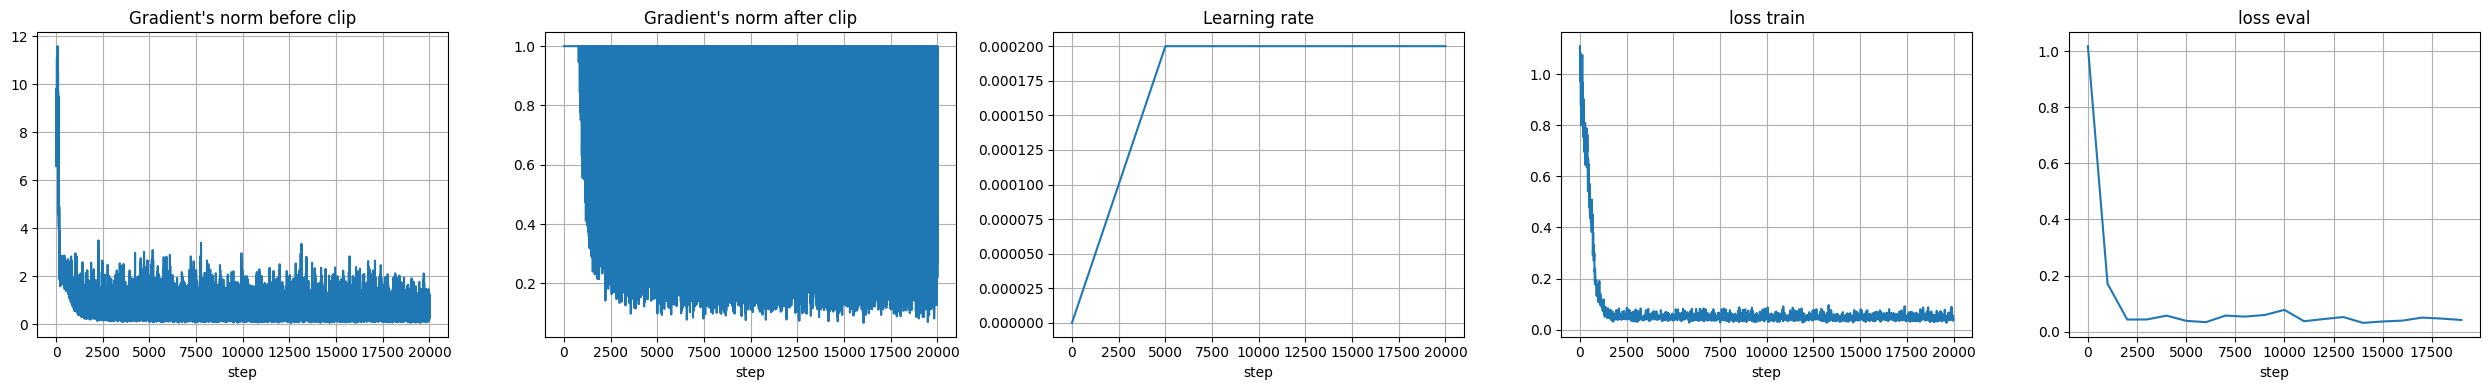

  2%|▏         | 20000/1000001 [1:16:06<144:17:40,  1.89it/s]

[step 20000] Generated Images RK45


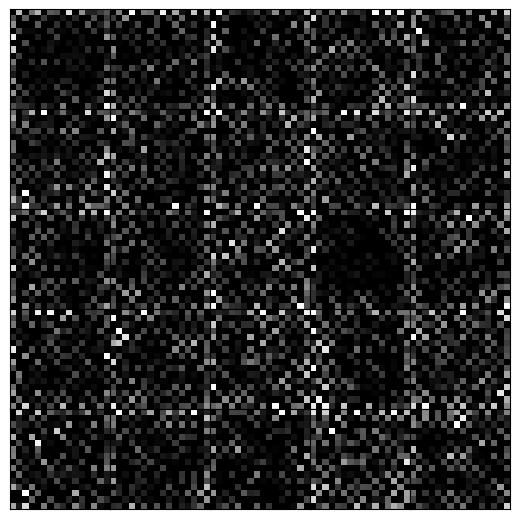

[step 20000] Init Images


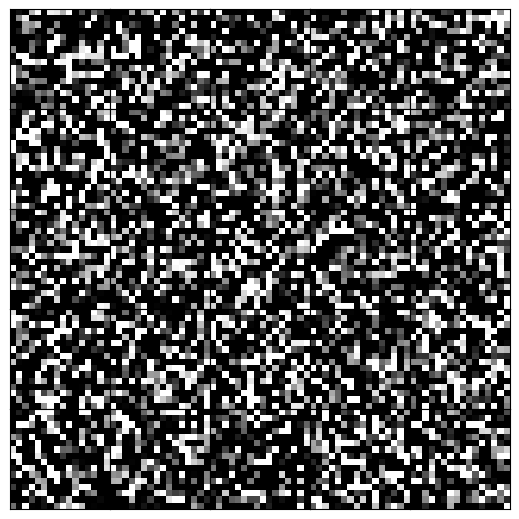

[step 20000] Trajectories RK45


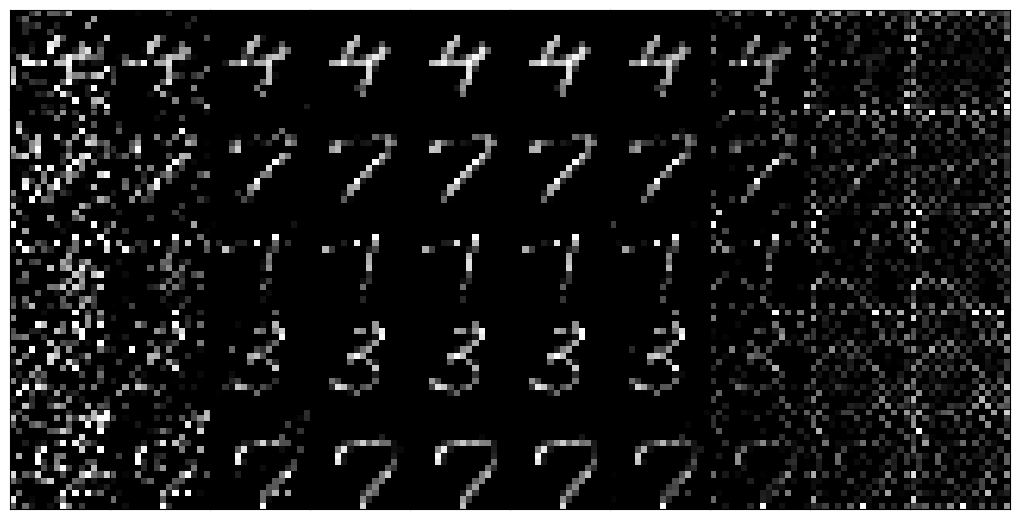

[step 20000] Generated Images Euler


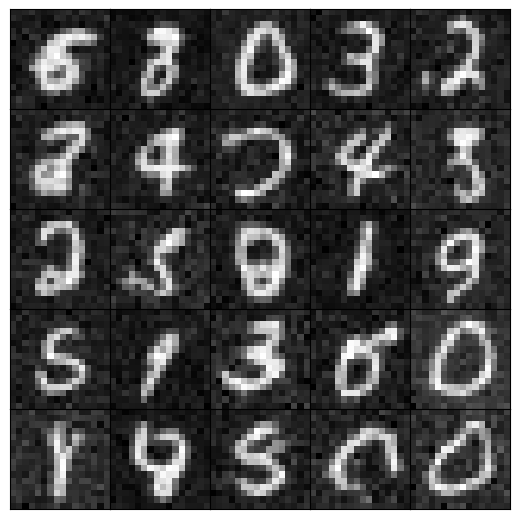

  2%|▏         | 20155/1000001 [1:16:54<62:18:32,  4.37it/s]  


KeyboardInterrupt: 

In [11]:
efm = EFM(config)
net, state = efm.train(train_loader, eval_loader,
                       net, optimizer, optimize_fn,
                       state)